# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar experimentos de Transfer Learning com modelos pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**) em blocos de código separados e independentes, invocando o módulo `src.transfer_learning`, conforme abordado no Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [8]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar configurações e motor de Transfer Learning de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.transfer_learning import train_and_evaluate_transfer_model

# Dicionário global para consolidar todos os resultados
resultados = {}

## 2. Experimento 1: ResNet-18

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão da **ResNet-18**.

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.001
Época [01/10] | Treino Loss: 0.0584 - Acc: 98.02% | Val Loss: 0.0086 - Acc: 99.89% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0216 - Acc: 99.46% | Val Loss: 0.0013 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0155 - Acc: 99.48% | Val Loss: 0.0034 - Acc: 99.94% 
Época [04/10] | Treino Loss: 0.0133 - Acc: 99.60% | Val Loss: 0.0014 - Acc: 99.94% 
Época [05/10] | Treino Loss: 0.0020 - Acc: 99.95% | Val Loss: 0.0001 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0211 - Acc: 99.47% | Val Loss: 0.0475 - Acc: 98.93% 
Época [07/10] | Treino Loss: 0.0149 - Acc: 99.64% | Val Loss: 0.0003 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0011 - Acc: 99.98% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 08/10.
Época [09/10] | Treino Loss: 0.0006 - Acc: 99.98% |

c:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\src\transfer_learning.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_d

[RESULTADO FINAL] Acurácia no Teste (RESNET18): 100.00%



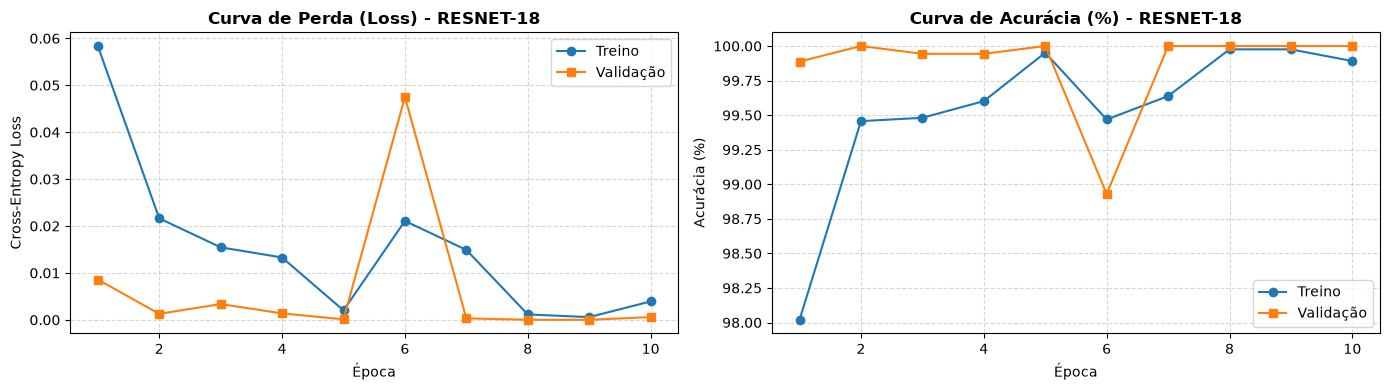

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



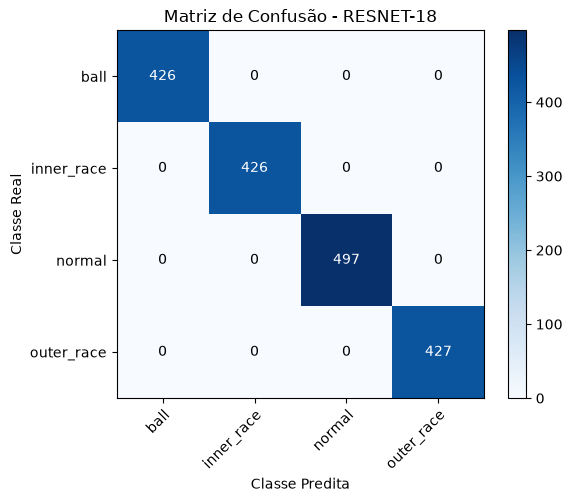

In [11]:
# Treinamento da ResNet-18
res_resnet = train_and_evaluate_transfer_model('resnet18', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['resnet18'] = res_resnet

# --- 1. Curvas de Aprendizado ---
hist = res_resnet['historico']
epocas_eixo = range(1, len(hist['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(epocas_eixo, hist['train_loss'], label='Treino', marker='o')
axs[0].plot(epocas_eixo, hist['val_loss'], label='Validação', marker='s')
axs[0].set_title('Curva de Perda (Loss) - RESNET-18', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(epocas_eixo, hist['train_acc'], label='Treino', marker='o')
axs[1].plot(epocas_eixo, hist['val_acc'], label='Validação', marker='s')
axs[1].set_title('Curva de Acurácia (%) - RESNET-18', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acurácia (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===')
print(classification_report(res_resnet['test_labels'], res_resnet['test_preds'], target_names=res_resnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_resnet['test_labels'], res_resnet['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_resnet['classes'], yticklabels=res_resnet['classes'],
       title='Matriz de Confusão - RESNET-18',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

## 3. Experimento 2: Inception-v3

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **Inception-v3** (com imagens redimensionadas para $299 \times 299$).

In [12]:
# Treinamento do Inception-v3
res_inception = train_and_evaluate_transfer_model('inception_v3', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['inception_v3'] = res_inception

# --- 1. Curvas de Aprendizado ---
hist = res_inception['historico']
epocas_eixo = range(1, len(hist['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(epocas_eixo, hist['train_loss'], label='Treino', marker='o')
axs[0].plot(epocas_eixo, hist['val_loss'], label='Validação', marker='s')
axs[0].set_title('Curva de Perda (Loss) - INCEPTION-V3', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(epocas_eixo, hist['train_acc'], label='Treino', marker='o')
axs[1].plot(epocas_eixo, hist['val_acc'], label='Validação', marker='s')
axs[1].set_title('Curva de Acurácia (%) - INCEPTION-V3', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acurácia (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===')
print(classification_report(res_inception['test_labels'], res_inception['test_preds'], target_names=res_inception['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_inception['test_labels'], res_inception['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_inception['classes'], yticklabels=res_inception['classes'],
       title='Matriz de Confusão - INCEPTION-V3',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=0.001
Época [01/10] | Treino Loss: 0.0847 - Acc: 97.20% | Val Loss: 0.0111 - Acc: 99.83% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0309 - Acc: 99.11% | Val Loss: 0.0059 - Acc: 99.89% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0145 - Acc: 99.58% | Val Loss: 0.0025 - Acc: 99.94% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0271 - Acc: 99.20% | Val Loss: 0.0031 - Acc: 99.94% 
Época [05/10] | Treino Loss: 0.0056 - Acc: 99.82% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0050 - Acc: 99.84% | Val Loss: 0.0024 - Acc: 99.89% 
Época [07/10] | Treino Loss: 0.0340 - Acc: 98.97% | Val Loss: 0.0007 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0063 - Acc: 99.81% | Val Loss: 0.0011 - Acc: 99.94% 
Época [09/10] | Treino Loss: 0.0079 - Acc: 99.73%

KeyboardInterrupt: 

## 4. Experimento 3: EfficientNet-B0

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **EfficientNet-B0**.

In [ ]:
# Treinamento do EfficientNet-B0
res_efficientnet = train_and_evaluate_transfer_model('efficientnet_b0', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['efficientnet_b0'] = res_efficientnet

# --- 1. Curvas de Aprendizado ---
hist = res_efficientnet['historico']
epocas_eixo = range(1, len(hist['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(epocas_eixo, hist['train_loss'], label='Treino', marker='o')
axs[0].plot(epocas_eixo, hist['val_loss'], label='Validação', marker='s')
axs[0].set_title('Curva de Perda (Loss) - EFFICIENTNET-B0', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(epocas_eixo, hist['train_acc'], label='Treino', marker='o')
axs[1].plot(epocas_eixo, hist['val_acc'], label='Validação', marker='s')
axs[1].set_title('Curva de Acurácia (%) - EFFICIENTNET-B0', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acurácia (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===')
print(classification_report(res_efficientnet['test_labels'], res_efficientnet['test_preds'], target_names=res_efficientnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_efficientnet['test_labels'], res_efficientnet['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_efficientnet['classes'], yticklabels=res_efficientnet['classes'],
       title='Matriz de Confusão - EFFICIENTNET-B0',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

## 5. Tabela Comparativa Geral de Desempenho (Monografia - Tabela 4/7)

Tabela resumida final para inclusão direta no Capítulo de Resultados do TCC.

In [ ]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)
print(f'{"BearingCNN (Própria)":<22s} | {"Treino do Zero":<16s} | {"99.94%":<18s} | {"99.89%":<18s}')

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')